# **Google Drive Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Path Set**

In [ ]:
import os
dataset_path = '/content/drive/MyDrive/ChiliDoc_Dataset'
print(os.listdir(dataset_path))

['Nutrition_Deficiency', 'Cercospora_Leaf_Spot', 'Bacterial_Spot', 'Healthy_Leaf', 'Curl_Virus', 'White_Spot', 'chilidoc_cnn_model.h5']


# **Install Required Libraries**

In [ ]:
!pip install transformers torch torchvision datasets scikit-learn

# **Libraries Import**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

# **Create Custom Dataset Class**

In [ ]:
class ChiliDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.root_dir = root_dir
        self.processor = processor
        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []

        for idx, cls in enumerate(self.classes):
            cls_folder = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_folder):
                self.image_paths.append(os.path.join(cls_folder, img_name))
                self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        pixel_values = self.processor(image, return_tensors="pt")['pixel_values'].squeeze(0)
        return pixel_values, label

# **Processor & Dataset Load**

In [ ]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
full_dataset = ChiliDataset(dataset_path, processor)

# Train/Val split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

Classes: ['Bacterial_Spot', 'Cercospora_Leaf_Spot', 'Curl_Virus', 'Healthy_Leaf', 'Nutrition_Deficiency', 'White_Spot']


# **Pretrained ViT Model Load**

In [ ]:
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

# **Optimizer Set**

In [ ]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=5e-5)

# **Model Train**

In [ ]:
epochs = 5
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for pixel_values, labels in train_loader:
        pixel_values, labels = pixel_values.to(device), labels.to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/5 - Loss: 0.2944
Epoch 2/5 - Loss: 0.0271
Epoch 3/5 - Loss: 0.0193
Epoch 4/5 - Loss: 0.0079
Epoch 5/5 - Loss: 0.0086


# **Validation Accuracy Check**

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for pixel_values, labels in val_loader:
        pixel_values, labels = pixel_values.to(device), labels.to(device)
        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 98.76%


# **Loss Graph**

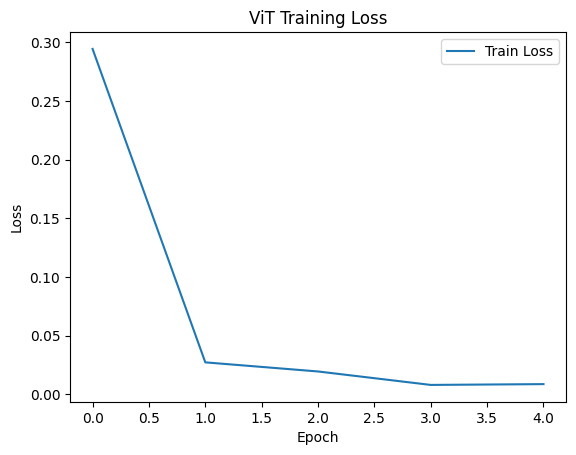

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ViT Training Loss')
plt.legend()
plt.show()

# **Model Save**

In [ ]:
model.save_pretrained('/content/drive/MyDrive/ChiliDoc_Dataset/chilidoc_vit_model')
processor.save_pretrained('/content/drive/MyDrive/ChiliDoc_Dataset/chilidoc_vit_model')
print("ViT Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ViT Model saved!
